## 02 Feature Selection
Daten laden aus sample.ipynb


In [52]:
import os
print(os.getcwd())

c:\Dokumente_lokal\BA_Project


In [53]:
import pandas as pd
df = pd.read_csv(r'C:\Dokumente_lokal\BA_Project\Merged_items_train.csv')

### Time Split 
Time Split muss erstellt werden, da die Daten einen Zeitverlauf haben. Es ist wichtig, dass in den verschiedenen Datensätzen kein "Zukunftswissen" vorhanden ist. Damit könnte das Modell mit Daten trainiert werden, welche erst in Zukunft eintretten. Somit könnte es in die Zukunft sehen, was gerade für Vorhersagen kontraproduktiv ist.
Die Verteilung ist wie folgt:
- Train         Tag 01-60   ca. 65%
- Validation    Tag 61-75   ca. 16%
- Test          Tag 76-92   ca. 19%


In [54]:
df = df.sort_values("day")

train = df[df["day"]<= 60]
validation = df[(df["day"] > 60) & (df["day"] <= 75)]
test = df[df["day"] > 75]

### Anzahl Events pro Split:

In [55]:
print("Train orders:" ,len(train))
print("Validation orders:" ,len(validation))
print("Test orders:", len(test))

Train orders: 1708472
Validation orders: 490672
Test orders: 556859


### Kaufrate pro Split:

In [56]:
print("Train orders:", train["order"].mean())
print("Validation orders:", validation["order"].mean())
print("Test orders:", test["order"].mean())

Train orders: 0.26530431871286153
Validation orders: 0.23611699872827469
Test orders: 0.24417132523672958


## 02 Feature Engineering
### 01 - Filter Methoden

In [57]:
df_train = train.copy()

### 01.1 Numerische Features
#### 01.1.1 Korrelaion

In [58]:
numeric_features = df_train.select_dtypes(include= ['int','float']).columns
print(numeric_features)

Index(['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice',
       'click', 'basket', 'order', 'price', 'revenue', 'genericProduct',
       'salesIndex', 'rrp', 'manufacturer_freq_enc', 'pharmForm_freq_enc',
       'category_freq_enc', 'group_freq_enc', 'manufacturer_target_enc',
       'pharmForm_target_enc', 'category_target_enc', 'group_target_enc',
       'is_multipack', 'pack_n', 'pack_size', 'has_campaign', 'day_7',
       'day_14', 'day_30', 'competitorPrice_clean', 'price_clean',
       'rrp_clean'],
      dtype='object')


### Korrelationsmatrix

<function matplotlib.pyplot.show(close=None, block=None)>

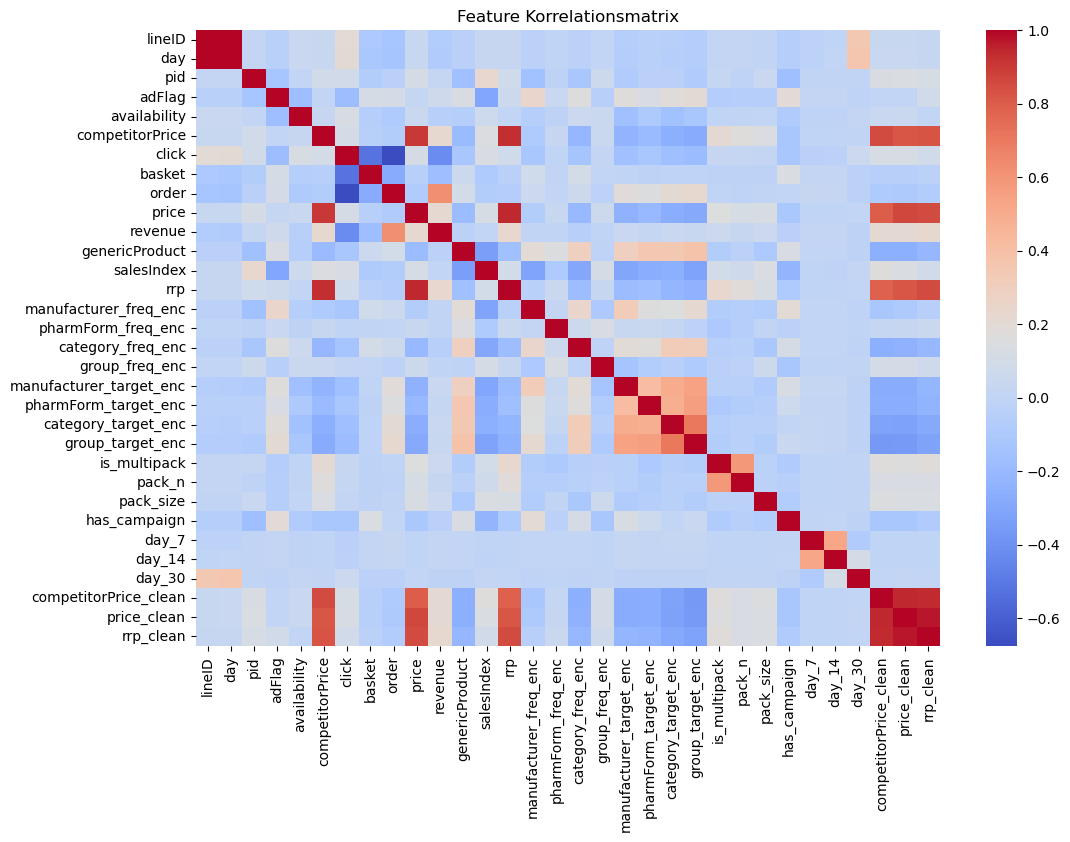

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train[numeric_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap = "coolwarm")
plt.title("Feature Korrelationsmatrix")
plt.show

### Korrelation in Zahlen
#### Alle Korrelationen

In [51]:
corr_all = df_train[numeric_features].corr()
print(corr_all)

                           lineID       day       pid    adFlag  availability  \
lineID                   1.000000  0.994014  0.011988 -0.043667      0.039332   
day                      0.994014  1.000000  0.012678 -0.044258      0.040637   
pid                      0.011988  0.012678  1.000000 -0.132461      0.010405   
adFlag                  -0.043667 -0.044258 -0.132461  1.000000     -0.174478   
availability             0.039332  0.040637  0.010405 -0.174478      1.000000   
competitorPrice          0.033074  0.034880  0.089416  0.011370      0.029699   
click                    0.198165  0.205010  0.086740 -0.181142      0.123607   
basket                  -0.105333 -0.108702 -0.072548  0.116084     -0.055624   
order                   -0.131996 -0.136788 -0.034962  0.103573     -0.091029   
price                    0.032295  0.034331  0.112775  0.020339      0.049351   
revenue                 -0.078075 -0.080655  0.021697  0.070995     -0.050516   
genericProduct          -0.0

#### Nur starke Korrelationen > 0.8

In [ ]:
import numpy as np
corr = df_train[numeric_features].corr()

# Korrelation gleicher Features aussortieren
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Nur starke Korrelationen > 0.8
strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

strong_corr = strong_corr[abs(strong_corr['Correlation']) > 0.8]

print(strong_corr.sort_values(by="Correlation", ascending=False))

                 Feature 1              Feature 2  Correlation
0                   lineID                    day     0.994014
495            price_clean              rrp_clean     0.969346
493  competitorPrice_clean            price_clean     0.946111
246                  price                    rrp     0.941444
494  competitorPrice_clean              rrp_clean     0.939187
152        competitorPrice                    rrp     0.929399
148        competitorPrice                  price     0.907907
263                  price            price_clean     0.862679
168        competitorPrice  competitorPrice_clean     0.854967
264                  price              rrp_clean     0.851900
342                    rrp              rrp_clean     0.851820
170        competitorPrice              rrp_clean     0.823735
341                    rrp            price_clean     0.821874
169        competitorPrice            price_clean     0.817505
262                  price  competitorPrice_clean     0

#### Korrelation mit Targetvariabel "order"

In [48]:
corr_target_df = corr_target.reset_index()
corr_target_df.columns = ["Feature", "Correlation with Order"]
print(corr_target_df)

                    Feature  Correlation with Order
0                   revenue                0.624374
1          group_target_enc                0.224534
2       category_target_enc                0.205390
3   manufacturer_target_enc                0.182207
4      pharmForm_target_enc                0.151984
5                    adFlag                0.103573
6            genericProduct                0.091205
7         category_freq_enc                0.062132
8     manufacturer_freq_enc                0.056799
9                     day_7                0.029009
10                   day_14                0.023398
11             has_campaign                0.010745
12       pharmForm_freq_enc                0.007629
13                pack_size               -0.000827
14             is_multipack               -0.008087
15                   pack_n               -0.011193
16           group_freq_enc               -0.023644
17                   day_30               -0.033223
18          

### 01.1.2 Mutual Information
Misst wie viel Information ein Feature über das Target enthält. Sklearn nutzt den k-nearest neighbor Ansatz.
Für jeden Datenpunkt werden die k nächsten Nachbarn im Feature Raum gesucht. Daraus wird geschätzt, wie dicht die Punkte liegen wie stark X und Y zusammen auftrettten.
Misst wie stark sich die Wahrscheinlichkeit von Y ändert, wenn X bekannt ist.
Gut weil:
- Rabattwirkungen haben oft Schwellen (ab einem Zeitpunkt sinken die orders, trotz steigendem Rabatt)
- Preiswirkungen sind oft nicht linear
- Verfügbarkeit wirkt sprunghaft

-> Sehr rechenintensiv, besser mit sample machen

In [61]:
from sklearn.feature_selection import mutual_info_classif

# Features und Target definieren
X = df_train.drop(columns=["order"])
y = df_train["order"]

# Missing Flag für competitorPrice erstellen, damit klar ist wie mit NaN umgegangen wird (0 = Preis vorhanden, 1 = Preis missing)
X["competitorPrice_missing"] = X["competitorPrice"].isna().astype(int)

# nummerische Features
X_numeric = X.select_dtypes(include=["int","float"])

# NaN müssen trotzdem ersetzt werden
X_numeric = X_numeric.fillna(X_numeric.median())

# Mutual Information berechnen
mi_scores = mutual_info_classif(X_numeric, y, random_state=42)

# Ergebnisse in Tabelle
mi_scores = pd.Series(mi_scores, index=X_numeric.columns)

mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)


revenue                    0.578779
click                      0.440167
lineID                     0.280377
availability               0.191110
salesIndex                 0.127039
basket                     0.093770
adFlag                     0.067154
pid                        0.060117
day_7                      0.043139
pack_n                     0.038987
group_freq_enc             0.034350
rrp_clean                  0.033707
rrp                        0.033134
group_target_enc           0.030702
category_freq_enc          0.029195
pharmForm_freq_enc         0.027423
competitorPrice_clean      0.026277
category_target_enc        0.025807
manufacturer_freq_enc      0.025523
competitorPrice            0.025511
price_clean                0.025381
price                      0.023788
manufacturer_target_enc    0.022246
pharmForm_target_enc       0.021891
has_campaign               0.021570
day                        0.018485
day_14                     0.018021
pack_size                  0

#### Interpretation Werte
MI >= 0 -> Je höher der Wert, deso mehr Informationen über das Target enthält das Feature
| Wertbereich | Zusammenhang |
|-------------|--------------|
| 0           | kein Zusammenhang |
| 0.001 - 0.01 | sehr schwach |
| 0.01 - 0.05 | schwach |
| 0.05 - 0.15 | mittel |
| > 0.15      | stark |


Achtung revenue und click "kommen" quais aus orders, deshalb müssen sie entfernt werden.
LineID ist kein richitges Feature, weshalb auch dieses entfernt werden muss.

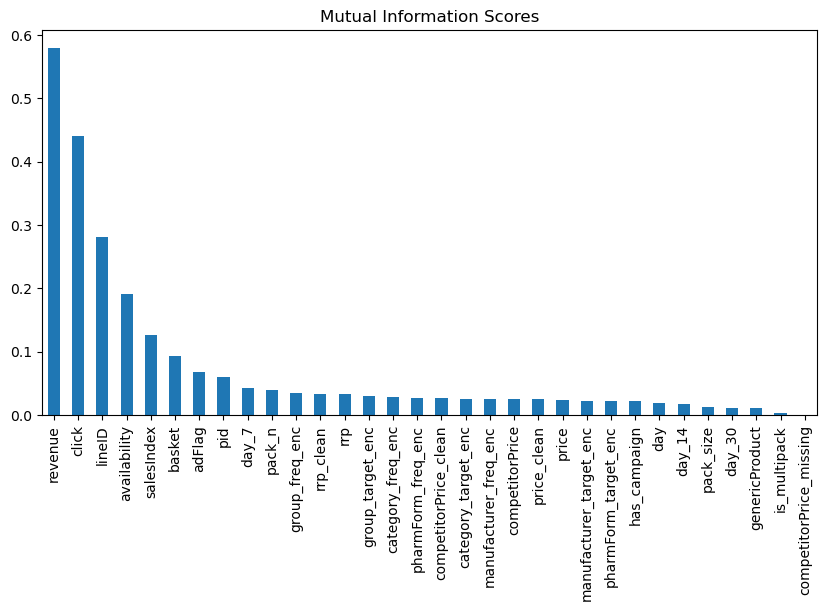

In [62]:
# Visualisierung
import matplotlib.pyplot as plt

mi_scores.plot.bar(figsize=(10,5))
plt.title("Mutual Information Scores")
plt.show()

### 01.2 Regressive Werte
#### 01.2.1 Mutual Information

In [ ]:
from sklearn.feature_selection import mutual_info_classif

x = df_train.drop(columns=["order"])
y = df_train["order"]